# 01 · §7.1 Quantitative Results (H1)

Per-(dataset, teacher) tables of test **mAP@R / R-Precision / Recall@K** (mean ± sem over ≥3 seeds) for the 5 students, plus the grouped mAP@R bar chart. Verdict by the §8 rule: *matches* if the interval overlaps the best baseline; *beats* only if mean > best baseline + 1 sem **and** the sign is consistent across teachers — reported per cell, never averaged over a sign flip.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # RKD/ on path
sys.path.insert(0, os.getcwd())
import analysis_utils as au
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df = pd.read_csv('results.csv')
cells = df[df.phase=='phase5'][['dataset','teacher']].dropna().drop_duplicates()
cells = list(cells.itertuples(index=False, name=None)); cells

[('cars196', 'resnet18'),
 ('cars196', 'convnext_tiny'),
 ('cub200', 'resnet18'),
 ('cub200', 'convnext_tiny')]

### Headline tables (one per cell)

In [3]:
for d,t in cells:
    print(f'=== {d} · {t} ===')
    tab = au.headline_table(df, d, t, 'test_mAP@R')
    display(tab)
    print('H1:', au.h1_verdict(tab), '\n')

=== cars196 · resnet18 ===


,student,median,mean,sem,n
4,triplet-only,0.0307,0.0324,0.0020,3
3,+RKD-D,0.0179,0.0181,0.0008,3
1,+RKD-A,0.0193,0.0194,0.0010,3
2,+RKD-D+RKD-A,0.0176,0.0176,0.0011,3
0,+Graph-RKD,0.0328,0.0341,0.0010,9


H1: Graph-RKD BEATS triplet-only (median 0.0328 > 0.0307) 

=== cars196 · convnext_tiny ===


,student,median,mean,sem,n
4,triplet-only,0.0307,0.0324,0.0020,3
3,+RKD-D,0.0205,0.0199,0.0024,3
1,+RKD-A,0.0229,0.0229,0.0016,2
2,+RKD-D+RKD-A,0.0193,0.0193,0.0008,2
0,+Graph-RKD,0.0335,0.0333,0.0013,6


H1: Graph-RKD BEATS triplet-only (median 0.0335 > 0.0307) 

=== cub200 · resnet18 ===


,student,median,mean,sem,n
4,triplet-only,0.0305,0.0305,0.0021,2
3,+RKD-D,0.0329,0.0329,0.0007,2
1,+RKD-A,0.0350,0.0350,0.0011,2
2,+RKD-D+RKD-A,0.0348,0.0348,0.0007,2
0,+Graph-RKD,0.0323,0.0315,0.0008,6


H1: Graph-RKD LOSES to +RKD-A (median 0.0323 < 0.0350) 

=== cub200 · convnext_tiny ===


,student,median,mean,sem,n
4,triplet-only,0.0305,0.0305,0.0021,2
3,+RKD-D,0.0298,0.0298,0.0001,2
1,+RKD-A,0.0307,0.0307,0.0005,2
2,+RKD-D+RKD-A,0.0308,0.0308,0.0002,2
0,+Graph-RKD,0.0302,0.0306,0.0005,6


H1: Graph-RKD LOSES to +RKD-D+RKD-A (median 0.0302 < 0.0308) 



### R-Precision and Recall@1 (secondary)

In [4]:
for m in ['test_R_precision','test_recall@1']:
    print('---', m, '---')
    for d,t in cells: display(au.headline_table(df, d, t, m))

--- test_R_precision ---


,student,median,mean,sem,n
4,triplet-only,0.0875,0.0914,0.0043,3
3,+RKD-D,0.0648,0.0631,0.0019,3
1,+RKD-A,0.0679,0.0653,0.0031,3
2,+RKD-D+RKD-A,0.0646,0.0619,0.0030,3
0,+Graph-RKD,0.0895,0.0933,0.0024,9


,student,median,mean,sem,n
4,triplet-only,0.0875,0.0914,0.0043,3
3,+RKD-D,0.0694,0.0653,0.0058,3
1,+RKD-A,0.0718,0.0718,0.0022,2
2,+RKD-D+RKD-A,0.0655,0.0655,0.0006,2
0,+Graph-RKD,0.0931,0.0928,0.0028,6


,student,median,mean,sem,n
4,triplet-only,0.0834,0.0834,0.0020,2
3,+RKD-D,0.0875,0.0875,0.0012,2
1,+RKD-A,0.0928,0.0928,0.0028,2
2,+RKD-D+RKD-A,0.0919,0.0919,0.0001,2
0,+Graph-RKD,0.0837,0.0839,0.0010,6


,student,median,mean,sem,n
4,triplet-only,0.0834,0.0834,0.0020,2
3,+RKD-D,0.0822,0.0822,0.0005,2
1,+RKD-A,0.0846,0.0846,0.0008,2
2,+RKD-D+RKD-A,0.0850,0.0850,0.0007,2
0,+Graph-RKD,0.0807,0.0814,0.0012,6


--- test_recall@1 ---


,student,median,mean,sem,n
4,triplet-only,0.2096,0.2264,0.0180,3
3,+RKD-D,0.1377,0.1372,0.0058,3
1,+RKD-A,0.1405,0.1364,0.0075,3
2,+RKD-D+RKD-A,0.1359,0.1329,0.0067,3
0,+Graph-RKD,0.2284,0.2367,0.0075,9


,student,median,mean,sem,n
4,triplet-only,0.2096,0.2264,0.0180,3
3,+RKD-D,0.1477,0.1368,0.0144,3
1,+RKD-A,0.1509,0.1509,0.0081,2
2,+RKD-D+RKD-A,0.1337,0.1337,0.0057,2
0,+Graph-RKD,0.2412,0.2394,0.0082,6


,student,median,mean,sem,n
4,triplet-only,0.1430,0.1430,0.0091,2
3,+RKD-D,0.1609,0.1609,0.0019,2
1,+RKD-A,0.1724,0.1724,0.0016,2
2,+RKD-D+RKD-A,0.1613,0.1613,0.0004,2
0,+Graph-RKD,0.1491,0.1469,0.0019,6


,student,median,mean,sem,n
4,triplet-only,0.1430,0.1430,0.0091,2
3,+RKD-D,0.1450,0.1450,0.0015,2
1,+RKD-A,0.1476,0.1476,0.0001,2
2,+RKD-D+RKD-A,0.1511,0.1511,0.0035,2
0,+Graph-RKD,0.1403,0.1410,0.0028,6


### Grouped mAP@R bar chart (Figure for §7.1)

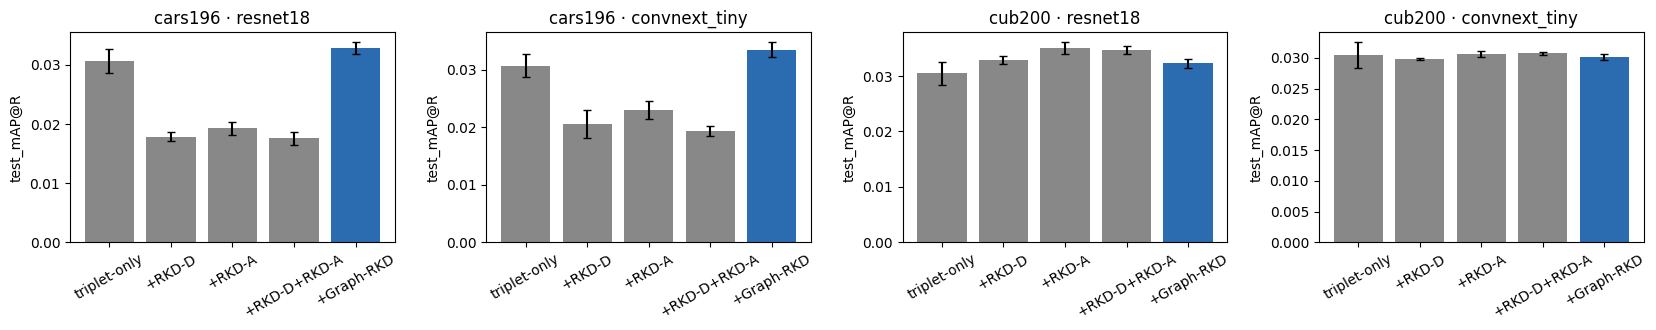

In [5]:
au.fig_h1_bar(df);